<a href="https://colab.research.google.com/github/Sinthia03/CVPR/blob/main/SinthiaSiddika(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np
import kagglehub

path = kagglehub.dataset_download("sunilthite/ovarian-cancer-classification-dataset")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/sunilthite/ovarian-cancer-classification-dataset/versions/1


In [ ]:

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


full_dataset = datasets.ImageFolder(path)

# Split into Training (80%) and Testing (20%)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_indices, test_indices = torch.utils.data.random_split(range(len(full_dataset)), [train_size, test_size])


train_dataset = Subset(full_dataset, train_indices)
train_dataset.dataset.transform = data_transforms['train']

test_dataset = Subset(full_dataset, test_indices)
test_dataset.dataset.transform = data_transforms['val']

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = full_dataset.classes
num_classes = len(class_names)

In [ ]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False


num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]


In [ ]:
import torch.nn.functional as F

# 1. Training Loop
num_epochs = 2  # Small epoch size for speed
print(f"Starting Training on {device}...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)


        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")


model.eval()
all_preds = []
all_labels = []
all_probs = []

print("\nEvaluating model...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)

        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())


print("\n" + "="*30)
print("FINAL CLASSIFICATION REPORT")
print("="*30)

# Accuracy, Precision, Recall, F1
print(classification_report(all_labels, all_preds, target_names=class_names))

# AUC-ROC Score
auc_score = roc_auc_score(all_labels, all_probs)
print(f"AUC-ROC Score: {auc_score:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

Starting Training on cuda...
Epoch 1/2 - Loss: 0.3243
Epoch 2/2 - Loss: 0.3125

Evaluating model...

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Test_Images       1.00      0.00      0.00       616
Train_Images       0.91      1.00      0.95      6241

    accuracy                           0.91      6857
   macro avg       0.96      0.50      0.48      6857
weighted avg       0.92      0.91      0.87      6857

AUC-ROC Score: 0.4931

Confusion Matrix:
[[   1  615]
 [   0 6241]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


#  Train and Test
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Re-wrap subsets
train_data = ApplyTransform(train_dataset, data_transforms['train'])
test_data = ApplyTransform(test_dataset, data_transforms['val'])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# 2. ENHANCED MODEL ARCHITECTURE
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze early layers
for param in model.parameters():
    param.requires_grad = False


num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, num_classes)
)

model = model.to(device)

# 3. OPTIMIZER & SCHEDULER
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# 4. INCREASED EPOCHS TRAINING
num_epochs = 15
print(f"Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader.dataset):.4f}")

# 5. EVALUATION & ROC CURVE PLOTTING
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

# Calculate ROC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

Training for 15 epochs...


TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>

Training for 15 epochs...
Epoch 1/15 - Loss: 0.3224
Epoch 2/15 - Loss: 0.3149
Epoch 3/15 - Loss: 0.3091
Epoch 4/15 - Loss: 0.3086
Epoch 5/15 - Loss: 0.3079
Epoch 6/15 - Loss: 0.3019
Epoch 7/15 - Loss: 0.3018
Epoch 8/15 - Loss: 0.3018
Epoch 9/15 - Loss: 0.3019
Epoch 10/15 - Loss: 0.3017
Epoch 11/15 - Loss: 0.3015
Epoch 12/15 - Loss: 0.3004
Epoch 13/15 - Loss: 0.3012
Epoch 14/15 - Loss: 0.3008
Epoch 15/15 - Loss: 0.3012


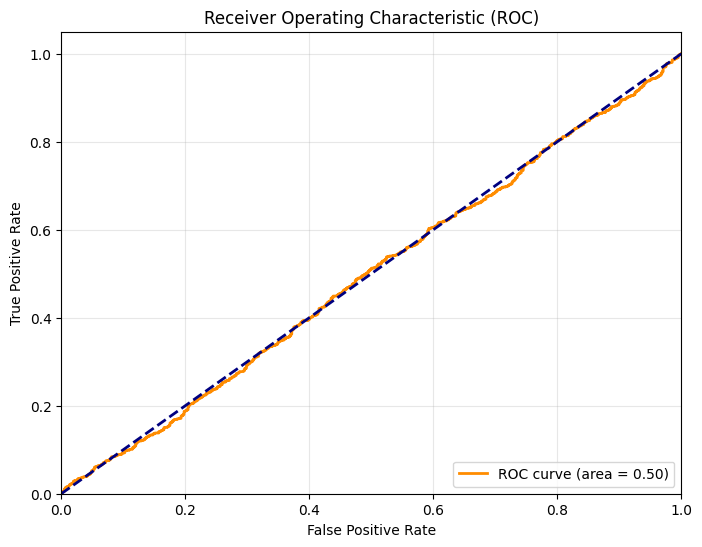


Final AUC-ROC Score: 0.4957


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


full_dataset.transform = None

class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


train_data = ApplyTransform(train_dataset, data_transforms['train'])
test_data = ApplyTransform(test_dataset, data_transforms['val'])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


model = models.resnet18(weights='IMAGENET1K_V1')


for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, num_classes)
)

model = model.to(device)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

#  TRAINING: 15 EPOCHS
num_epochs = 15
print(f"Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

#EVALUATION & ROC CURVE
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())

        all_probs.extend(probs[:, 1].cpu().numpy())

# Calculate ROC curve metrics
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"\nFinal AUC-ROC Score: {roc_auc:.4f}")


FINAL TEST ACCURACY: 91.02%
              precision    recall  f1-score   support

 Test_Images       0.00      0.00      0.00       616
Train_Images       0.91      1.00      0.95      6241

    accuracy                           0.91      6857
   macro avg       0.46      0.50      0.48      6857
weighted avg       0.83      0.91      0.87      6857



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


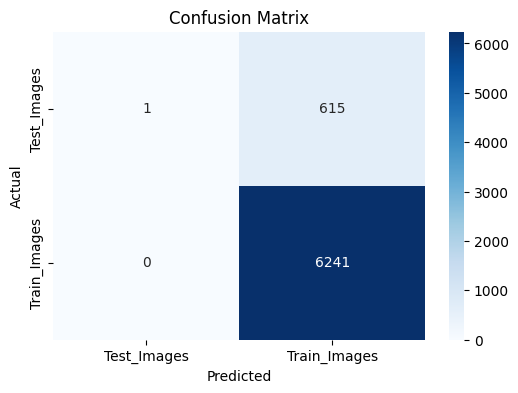

In [ ]:
from sklearn.metrics import accuracy_score


all_preds = (np.array(all_probs) > 0.5).astype(int)


accuracy = accuracy_score(all_labels, all_preds)

print("\n" + "="*30)
print(f"FINAL TEST ACCURACY: {accuracy:.2%}")
print("="*30)



print(classification_report(all_labels, all_preds, target_names=class_names))


import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

for param in model.layer4.parameters():
    param.requires_grad = True



optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4}
])



scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


for epoch in range(num_epochs):
    model.train()


    # Update the learning rate
    scheduler.step()

    #Print current LR to track progress
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} - Current LR: {current_lr}")

Epoch 1 - Current LR: 1e-05
Epoch 2 - Current LR: 1e-05
Epoch 3 - Current LR: 1e-05
Epoch 4 - Current LR: 1e-05
Epoch 5 - Current LR: 1.0000000000000002e-06
Epoch 6 - Current LR: 1.0000000000000002e-06
Epoch 7 - Current LR: 1.0000000000000002e-06
Epoch 8 - Current LR: 1.0000000000000002e-06
Epoch 9 - Current LR: 1.0000000000000002e-06
Epoch 10 - Current LR: 1.0000000000000002e-07
Epoch 11 - Current LR: 1.0000000000000002e-07
Epoch 12 - Current LR: 1.0000000000000002e-07
Epoch 13 - Current LR: 1.0000000000000002e-07
Epoch 14 - Current LR: 1.0000000000000002e-07
Epoch 15 - Current LR: 1.0000000000000004e-08


/tmp/ipykernel_9177/3748594521.py:22: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


In [ ]:

num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()


        optimizer.step()

        running_loss += loss.item() * inputs.size(0)


    scheduler.step()


    current_lr = optimizer.param_groups[0]['lr']
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - LR: {current_lr:.2e}")

Epoch 1/15 - Loss: 0.3007 - LR: 1.00e-08
Epoch 2/15 - Loss: 0.3014 - LR: 1.00e-08
Epoch 3/15 - Loss: 0.3011 - LR: 1.00e-08
Epoch 4/15 - Loss: 0.3014 - LR: 1.00e-08
Epoch 5/15 - Loss: 0.3011 - LR: 1.00e-09
Epoch 6/15 - Loss: 0.3009 - LR: 1.00e-09
Epoch 7/15 - Loss: 0.3007 - LR: 1.00e-09
Epoch 8/15 - Loss: 0.3009 - LR: 1.00e-09


KeyboardInterrupt: 

In [ ]:

def count_parameters(model):

    return sum(p.numel() for p in model.parameters() if p.requires_grad)

trainable_params = count_parameters(model)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Percentage Trainable: {100 * trainable_params / total_params:.2f}%")

Total Parameters: 11,571,010
Trainable Parameters: 8,788,226
Percentage Trainable: 75.95%


In [ ]:

class_names = full_dataset.classes
num_classes = len(class_names)


class_to_idx = full_dataset.class_to_idx

print(f"Total Number of Classes: {num_classes}")
print(f"Class Names: {class_names}")
print(f"Class to Index Mapping: {class_to_idx}")

from collections import Counter
targets = [label for _, label in full_dataset.samples]
distribution = Counter(targets)

print("\nImage Distribution per Class:")
for idx, count in distribution.items():
    print(f"Label '{class_names[idx]}' (Index {idx}): {count} images")

Total Number of Classes: 2
Class Names: ['Test_Images', 'Train_Images']
Class to Index Mapping: {'Test_Images': 0, 'Train_Images': 1}

Image Distribution per Class:
Label 'Test_Images' (Index 0): 3082 images
Label 'Train_Images' (Index 1): 31203 images
